In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

from yellowbrick.cluster import KElbowVisualizer

In [2]:
#import warnings
#warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('data/olist_rfm.csv')

In [4]:
df.head()

,customer_unique_id,recency,frequency,monetary
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38
1,af07308b275d755c9edb36a90c618231,85,1,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90


In [5]:
# remove customer_unique_id
df.drop(['customer_unique_id'], axis=1, inplace=True)
df.head()

,recency,frequency,monetary
0,380,2,65.38
1,85,1,118.70
2,70,1,159.90
3,333,1,45.00
4,246,1,19.90


In [6]:
df.head()

,recency,frequency,monetary
0,380,2,65.38
1,85,1,118.70
2,70,1,159.90
3,333,1,45.00
4,246,1,19.90


In [7]:
df.shape

(96096, 3)

In [8]:
df.dtypes

recency        int64
frequency      int64
monetary     float64
dtype: object

In [9]:
df.isna().sum()

recency      0
frequency    0
monetary     0
dtype: int64

In [10]:
quantiles = df.quantile(q=[0.25,0.5,0.75])
quantiles

,recency,frequency,monetary
0.25,164.0,1.0,45.99
0.50,269.0,1.0,89.00
0.75,397.0,1.0,154.00


# Distribution

<AxesSubplot:xlabel='monetary', ylabel='Count'>

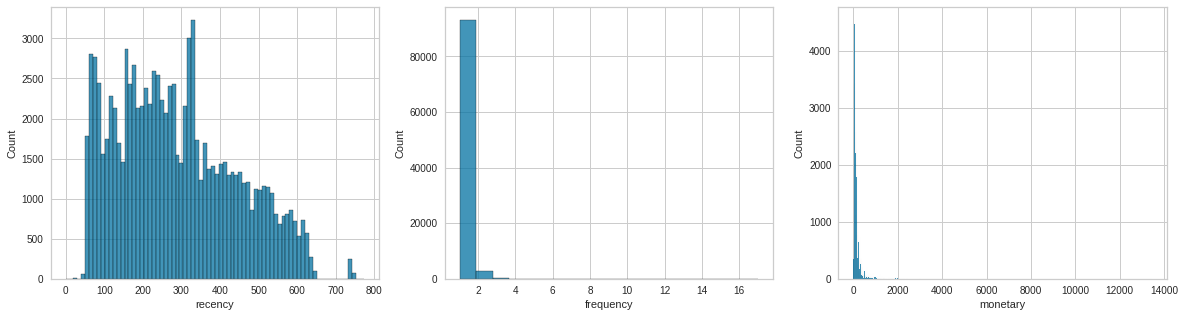

In [11]:
#Plot data distribution
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
sns.histplot(df['recency'])

plt.subplot(1,3,2)
sns.histplot(df['frequency'])

plt.subplot(1,3,3)
sns.histplot(df['monetary'])

In [12]:
#apply log transformation 
rfm_log = df[['recency', 'frequency', 'monetary']].apply(np.log, axis=1).round(3)

In [13]:
rfm_log.head()

,recency,frequency,monetary
0,5.940,0.693,4.180
1,4.443,0.000,4.777
2,4.248,0.000,5.075
3,5.808,0.000,3.807
4,5.505,0.000,2.991


<AxesSubplot:xlabel='monetary', ylabel='Count'>

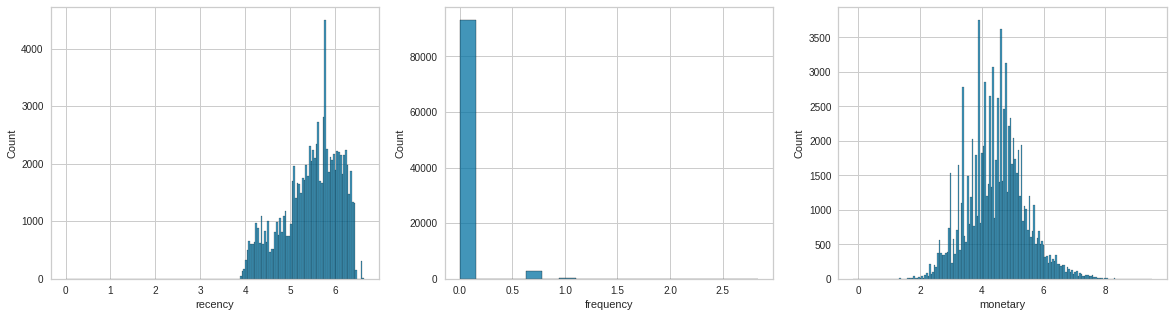

In [14]:
#Plot data distribution after log transformation
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
sns.histplot(rfm_log['recency'])

plt.subplot(1,3,2)
sns.histplot(rfm_log['frequency'])

plt.subplot(1,3,3)
sns.histplot(rfm_log['monetary'])

# Echantillon

In [15]:
#df_redux = df.sample(10000, random_state=1).copy()
#X = df_redux.copy()
X= df.copy() ## consomme de la mémoire
#categorical_columns = X.select_dtypes(['category','object']).columns
numerical_columns = X.select_dtypes(['int64','float64']).columns
ss = StandardScaler()
X[numerical_columns] = ss.fit_transform(X[numerical_columns])

In [16]:
X.head()

,recency,frequency,monetary
0,0.598963,4.502189,-0.350152
1,-1.323900,-0.162368,-0.104681
2,-1.421672,-0.162368,0.084993
3,0.292609,-0.162368,-0.443976
4,-0.274473,-0.162368,-0.559530


In [17]:
X.shape

(96096, 3)

In [18]:
df

,recency,frequency,monetary
0,380,2,65.38
1,85,1,118.70
2,70,1,159.90
3,333,1,45.00
4,246,1,19.90
...,...,...,...
96091,587,1,72.00
96092,253,1,174.90
96093,416,1,205.99
96094,282,1,359.98


# PCA

In [19]:
pca = PCA()

In [20]:
pca.fit(X)

PCA()

In [21]:
X.shape

(96096, 3)

In [22]:
# ajouter float point to plot

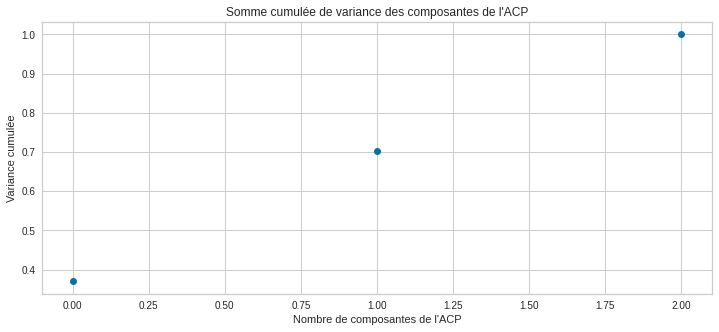

In [23]:
plt.figure(figsize=(12,5))
plt.title('Somme cumulée de variance des composantes de l\'ACP')
plt.xlabel('Nombre de composantes de l\'ACP')
plt.ylabel('Variance cumulée')
plt.plot(list(range(X.shape[1])),
         np.cumsum(pca.explained_variance_ratio_), 'o')

In [24]:
np.cumsum(pca.explained_variance_ratio_)[1]

0.7029684098506765

In [25]:
np.cumsum(pca.explained_variance_ratio_)[2]

1.0

In [26]:
colonnes_pca = X.columns

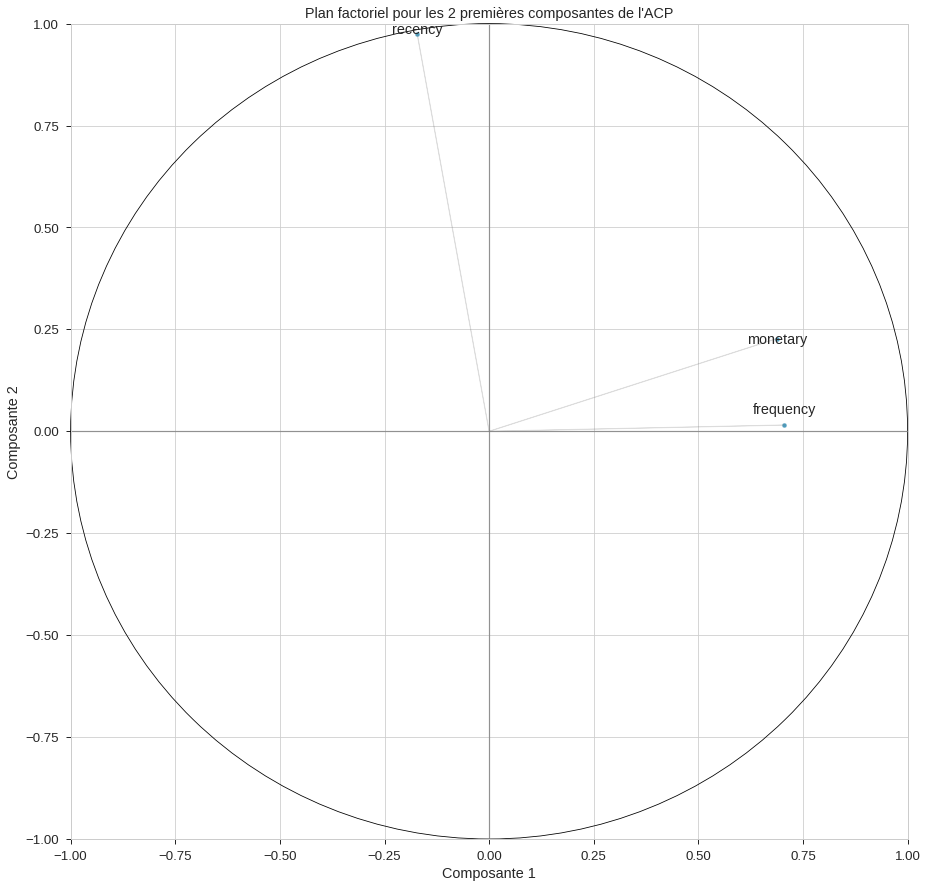

In [27]:
from matplotlib.patches import Circle
sns.set_context("paper", font_scale=1.5) 
plt.figure(figsize=(15,15))
chaine = "Plan factoriel pour les 2 premières composantes de l'ACP"
plt.title(chaine)
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
ax = plt.gca()
ax.add_patch(Circle([0,0], radius=1, color='black', fill=False, linestyle='-', 
                    clip_on=False))
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
x_pca = pca.components_[0,:]
y_pca = pca.components_[1,:]

sns.scatterplot(x = x_pca,
                y = y_pca,
               alpha = 0.7)
plt.plot([-1,1],[0,0], color='grey', alpha=0.8)
plt.plot([0,0],[-1,1], color='grey', alpha=0.8)

i = 0
for x,y,colonne in zip(x_pca,y_pca, colonnes_pca):

    plt.annotate(colonne, 
                 (x,y), 
                 textcoords="offset points", 
                 xytext=(0,5+np.random.randint(-10,10)),
                 ha='center') 
    ax.arrow(0, 0, x, y, head_width=0, head_length=0, fc='grey', ec='grey',
             alpha=0.2)


sns.set_context("paper", font_scale=1) 

# T-SNE

In [ ]:
tsne = TSNE(n_components=2)
T = tsne.fit_transform(X.copy())
# appliquer labels via dataframe (labels de dict kmeans)

In [ ]:
plt.figure(figsize=(8,8))
plt.title('Représentation des données via T-SNE')
sns.scatterplot(T[:,0], T[:,1])
# boucle 3 scatterplots selon label

# K-Means

In [30]:
# print avancement au fur et à mesure

In [32]:
kmeans = KMeans(n_clusters=5, 
                verbose=1, 
                random_state=0,
               #n_jobs=-1
               ).fit(X)

/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbdee5fb820>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 

Initialization complete
Iteration 0, inertia 91009.18366672176.
Iteration 1, inertia 81907.25496144156.
Iteration 2, inertia 81390.28767898108.
Iteration 3, inertia 81209.407010869.
Iteration 4, inertia 81147.7181579007.
Iteration 5, inertia 81113.61113584964.
Iteration 6, inertia 81078.21858837834.
Iteration 7, inertia 80976.17650206166.
Iteration 8, inertia 80841.29924439752.
Iteration 9, inertia 80778.3571407476.
Iteration 10, inertia 80740.42562777967.
Iteration 11, inertia 80721.68468438217.
Converged at iteration 11: center shift 7.992182389464443e-05 within tolerance 9.999999999988223e-05.
Initialization complete

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbdee8e8940>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling cty


Iteration 0, inertia 102369.11575433565.
Iteration 1, inertia 83189.464468773.
Iteration 2, inertia 81442.12041582703.
Iteration 3, inertia 80925.05816847555.
Iteration 4, inertia 80719.85520734763.
Iteration 5, inertia 80629.27995427106.
Iteration 6, inertia 80580.10107126695.
Iteration 7, inertia 80551.48366506172.
Iteration 8, inertia 80531.31485064076.
Iteration 9, inertia 80521.46989741159.
Iteration 10, inertia 80516.75162978917.
Converged at iteration 10: center shift 3.490935504992692e-05 within tolerance 9.999999999988223e-05.
Initialization complete


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbdf2ae3a60>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Iteration 0, inertia 121638.03198649017.
Iteration 1, inertia 88697.98608592268.
Iteration 2, inertia 83194.15149843182.
Iteration 3, inertia 81330.13157599958.
Iteration 4, inertia 80859.347036491.
Iteration 5, inertia 80777.34304911175.
Iteration 6, inertia 80741.1831196015.
Iteration 7, inertia 80721.82201279848.
Iteration 8, inertia 80717.20007276387.
Iteration 9, inertia 80716.10107805967.
Converged at iteration 9: center shift 8.544573134510448e-05 within tolerance 9.999999999988223e-05.
Initialization complete
Iteration 0, inertia 91393.52209241518.


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbe17f93160>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Iteration 1, inertia 81369.18091823948.
Iteration 2, inertia 81172.43291464951.
Iteration 3, inertia 81074.23000606264.
Iteration 4, inertia 81049.51612554665.
Iteration 5, inertia 80993.29103908243.
Iteration 6, inertia 80871.50271102587.
Iteration 7, inertia 80768.65240780238.
Iteration 8, inertia 80715.38347739981.
Iteration 9, inertia 80690.21954871231.
Iteration 10, inertia 80683.89687344947.
Converged at iteration 10: center shift 4.073417611677924e-05 within tolerance 9.999999999988223e-05.
Initialization complete
Iteration 0, inertia 100029.71870169911.
Iteration 1, inertia 84413.22080268964.
Iteration 2, inertia 82562.26507265678.
Iteration 3, inertia 81915.88392046311.
Iteration 4, inertia 81573.10301058454.
Iteration 5, inertia 81367.25056046197.
Iteration 6, inertia 81247.65918480334.
Iteration 7, inertia 81186.07636617695.
Iteration 8, inertia 81104.38401084971.
Iteration 9, inertia 80975.093061242.
Iteration 10, inertia 80880.62595673183.
Iteration 11, inertia 80826.32251

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fbdee8e8310>
Traceback (most recent call last):
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/mijka/.pyenv/versions/3.9.7/envs/data_p4/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Initialization complete
Iteration 0, inertia 119789.53697831614.
Iteration 1, inertia 87899.11546398954.
Iteration 2, inertia 84314.03342253827.
Iteration 3, inertia 82832.4815798408.
Iteration 4, inertia 82034.6669234893.
Iteration 5, inertia 81568.41285971584.
Iteration 6, inertia 81244.87178361739.
Iteration 7, inertia 81056.14728735421.
Iteration 8, inertia 80909.02883162747.
Iteration 9, inertia 80846.36882136669.
Iteration 10, inertia 80816.07838565164.
Iteration 11, inertia 80802.99913350967.
Iteration 12, inertia 80793.84713885853.
Iteration 13, inertia 80783.13410781896.
Iteration 14, inertia 80748.64234138634.
Iteration 15, inertia 80703.97156424331.
Iteration 16, inertia 80691.61180091857.
Iteration 17, inertia 80687.38822138023.
Iteration 18, inertia 80684.41711489088.
Iteration 19, inertia 80682.12090475365.
Iteration 20, inertia 80681.15575224067.
Iteration 21, inertia 80680.73410550729.
Converged at iteration 21: center shift 1.4179763181920371e-05 within tolerance 9.999

In [ ]:
kmeans.labels_

### coefficient de silhouette

In [29]:
silhouettes_kmeans = {}
dict_kmeans = {}
max_clusters = 4
for i in range(2,max_clusters):
    sil_var = silhouette_score(
                                X = X,
                                labels= list(dict_kmeans[(1,i)].labels_))
    print(sil_var)
    #print(dict_kmeans[(1,i)].labels_)
    silhouettes_kmeans[i] = sil_var

KeyError: (1, 2)

In [ ]:
plt.figure(figsize=(8,6)),
plt.title('Coefficient de silhouette moyen en fonction du nombre de clusters (kmeans)')
sns.scatterplot(x = list(silhouettes_kmeans.keys()),
               y = list(silhouettes_kmeans.values()))
plt.show()

In [ ]:
for key, value in silhouettes_kmeans.items():
    if value == max(silhouettes_kmeans.values()):
        print('le coefficient de silhouette est maximal pour {} clusters (score = {})'.format(key, value))
        nb_clusters = key

In [ ]:
nb_clusters

In [ ]:
## ne pas utiliser inertia juste silhouette silhouette score

In [ ]:


import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score


range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, n_init="auto", random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()


In [ ]:
##wcss stands for within cluster sum of squares


#wcss={}

#for k in range(2,15):
#    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000 , random_state=20)
#    km = km.fit(X)
#    wcss[k] = silhouette_score(X, km.labels_)
    
##Plot graph for the wcss values and the number of clusters

#sns.pointplot(x=list(wcss.keys()), y=list(wcss.values()))
#plt.xlabel('Number of clusters K')
#plt.ylabel('Sum of square distances')
#plt.title('Elbow method for optimal K')
#plt.show()

In [ ]:
# score de silhouette
#  sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)[source]

In [ ]:
km.labels_

In [ ]:
# kmeans sur toutes les variables

# DBscan

In [46]:
dbs = DBSCAN(eps = 1, 
             min_samples=5,
               n_jobs=-1
            ).fit(X.copy())

NameError: name 'DBSCAN' is not defined

In [ ]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(T[:,0], T[:,1], dbs.labels_)

### Clustering hiérarchique

In [ ]:
nb_clusters_agg = nb_clusters

In [ ]:
cah = AgglomerativeClustering(n_clusters = nb_clusters_agg
                             ).fit(X.copy())


In [47]:
graph = pd.DataFrame(data = [T[:,0], T[:,1], dict_kmeans[(1,11)].labels_]).T
graph.columns = ['X', 'Y', 'label_kmeans']

In [48]:
graph['x_pca'] = x_show
graph['y_pca'] = y_show
graph['z_pca'] = z_show

NameError: name 'x_show' is not defined

In [ ]:
graph

In [ ]:
plt.figure(figsize=(10,10))
plt.title('Représentation de la séparation des données du CAH via T-SNE')
sns.scatterplot(graph['X'], 
                graph['Y'], 
                hue = cah.labels_, 
                legend='full',
               palette=sns.color_palette("hls",nb_clusters_agg))
plt.legend(loc='upper left', labels=graph['label_kmeans'].unique())
plt.show()

In [ ]:
## ne pas utiliser PCA (permet de voir cassure) => focus TSNE (x y z)
## dbscan sur 3
# visualisation : tsne + labels/couleurs, scatterplot
# /!\ scaling / encoding données : dans la préparation des données, modelisation = modeles uniquement